# PX4 Phase 1 Closed-Loop PINN-MPC v3 Stable Hover Tuning

This notebook fixes the v17 position-state PINN checkpoint and tunes only the MPC.

The goal is deliberately conservative:

1. Pass learned-model `hover_hold` first.
2. Then test a small smooth position/altitude/yaw step.
3. Only after both are stable should this logic be connected to PX4/Gazebo online.

Compared with v2, v3 samples around a full horizon action sequence instead of repeatedly sampling from only the first action. It also adds stronger velocity/attitude safety penalties and smooth target transitions.


In [17]:
try:
    from google.colab import drive
    drive.mount('/content/drive')
except Exception as exc:
    print('Drive mount skipped:', type(exc).__name__, exc)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [18]:
import glob
import json
import math
import os
import random
import time
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

SEED = 7
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('device:', device)
print('torch:', torch.__version__)


device: cuda
torch: 2.10.0+cu128


In [19]:
NOTEBOOK_REVISION = 'v3_stable_hover_tuning'
MANUAL_CHECKPOINT_PATH = ''  # Set manually if auto-search misses it.
CHECKPOINT_GLOBS = [
    '/content/drive/MyDrive/Colab Result/PINN_MPC/px4_phase1_closed_loop_position_state_training_v17/**/px4_closed_loop_position_state_dynamics_pinn_v17.pt',
    '/content/drive/MyDrive/**/px4_closed_loop_position_state_dynamics_pinn_v17.pt',
    '/content/**/px4_closed_loop_position_state_dynamics_pinn_v17.pt',
]

DT = 0.05
MPC_HORIZON = 70          # 3.5 seconds at 20 Hz
MPC_SAMPLES = 512         # reduce to 192 on CPU if needed
MPC_ELITES = 48
MPC_ITERS = 5
CONTROL_INTERVAL_STEPS = 3  # 0.15 s receding-horizon update

# Setpoint bounds. Keep v3 inside the data envelope until hover and small steps are stable.
POS_LIMIT_M = 3.0
ALT_MIN_M = 21.0
ALT_MAX_M = 29.0
VEL_LIMIT_M_S = 0.35
VD_LIMIT_M_S = 0.22
YAW_OFFSET_LIMIT_DEG = 18.0

# Planning modes: hover_hold, small_step, mission
DEFAULT_SCENARIO = 'hover_hold'
RUN_SCENARIOS = ['hover_hold', 'small_step']

COST = dict(
    pos=28.0,
    alt=36.0,
    vel=10.0,
    yaw=2.5,
    terminal_pos=80.0,
    terminal_alt=90.0,
    attitude=0.45,
    rate=0.10,
    safety=900.0,
    effort_pos=0.03,
    effort_vel=0.25,
    effort_yaw=0.05,
    smooth=0.35,
    action_delta=0.65,
)

NOISE = dict(
    pos=0.18,
    alt=0.10,
    vel=0.035,
    vd=0.025,
    yaw=0.8,
)


In [20]:
def find_checkpoint():
    if MANUAL_CHECKPOINT_PATH:
        p = Path(MANUAL_CHECKPOINT_PATH)
        if p.exists():
            return p
        raise FileNotFoundError(f'MANUAL_CHECKPOINT_PATH not found: {p}')
    matches = []
    for pat in CHECKPOINT_GLOBS:
        matches.extend(Path(x) for x in glob.glob(pat, recursive=True))
    matches = sorted(set(p for p in matches if p.exists()))
    if not matches:
        raise FileNotFoundError('No v17 position-state PINN checkpoint found. Run the v17 position-state training notebook first or set MANUAL_CHECKPOINT_PATH.')
    return matches[-1]

CKPT_PATH = find_checkpoint()
print('CKPT_PATH:', CKPT_PATH)
ckpt = torch.load(CKPT_PATH, map_location='cpu', weights_only=False)
print('revision:', ckpt.get('revision'))
print('dataset:', ckpt.get('dataset_dir'))
STATE_COLS = ckpt['state_cols']
ACTION_COLS = ckpt['action_cols']
TARGET_COLS = ckpt['target_cols']
FEATURE_COLS = ckpt['feature_cols']
print('state:', STATE_COLS)
print('action:', ACTION_COLS)
print('feature dim:', len(FEATURE_COLS))

required_state = {'local_north_m', 'local_east_m', 'relative_altitude_m', 'yaw_deg'}
missing_state = sorted(required_state - set(STATE_COLS))
if missing_state:
    raise ValueError(f'This v2 MPC requires a position-state checkpoint. Missing state columns: {missing_state}')


CKPT_PATH: /content/drive/MyDrive/Colab Result/PINN_MPC/px4_phase1_closed_loop_position_state_training_v17/20260509_232358/px4_closed_loop_position_state_dynamics_pinn_v17.pt
revision: v17_position_state
dataset: /content/drive/MyDrive/px4_datasets/processed/px4_phase1_closed_loop_yawrel_position_state_dataset_v8_20260510_081623
state: ['local_north_m', 'local_east_m', 'relative_altitude_m', 'vel_north_m_s', 'vel_east_m_s', 'vel_down_m_s', 'roll_deg', 'pitch_deg', 'yaw_deg', 'roll_rate_rad_s', 'pitch_rate_rad_s', 'yaw_rate_rad_s']
action: ['ref_north_m', 'ref_east_m', 'ref_down_m', 'ref_north_m_s', 'ref_east_m_s', 'ref_down_m_s', 'ref_yaw_deg', 'ref_yaw_offset_deg']
feature dim: 40


In [21]:
class ResidualMLP(nn.Module):
    def __init__(self, in_dim, out_dim, hidden=256, depth=4, dropout=0.03):
        super().__init__()
        layers = []
        d = in_dim
        for _ in range(depth):
            layers += [nn.Linear(d, hidden), nn.LayerNorm(hidden), nn.SiLU(), nn.Dropout(dropout)]
            d = hidden
        layers.append(nn.Linear(d, out_dim))
        self.net = nn.Sequential(*layers)
    def forward(self, x):
        return self.net(x)

class Scaler:
    def __init__(self, payload):
        self.mean = torch.tensor(payload['mean'], dtype=torch.float32)
        self.std = torch.tensor(payload['std'], dtype=torch.float32).clamp_min(1e-8)
    def encode(self, x):
        return (torch.as_tensor(x, dtype=torch.float32) - self.mean) / self.std
    def decode(self, z):
        return z * self.std.to(z.device) + self.mean.to(z.device)

model_cfg = ckpt.get('model_config', {})
model = ResidualMLP(
    len(FEATURE_COLS), len(TARGET_COLS),
    hidden=int(model_cfg.get('hidden', 256)),
    depth=int(model_cfg.get('depth', 4)),
    dropout=float(model_cfg.get('dropout', 0.0)),
).to(device)
model.load_state_dict(ckpt['model_state_dict'])
model.eval()
x_scaler = Scaler(ckpt['x_scaler'])
y_scaler = Scaler(ckpt['y_scaler'])
state_index = {c: i for i, c in enumerate(STATE_COLS)}
target_index = {c: i for i, c in enumerate(TARGET_COLS)}
feature_index = {c: i for i, c in enumerate(FEATURE_COLS)}


In [22]:
def wrap_deg_np(x):
    return ((x + 180.0) % 360.0) - 180.0

def build_feature_matrix(states, actions, prev_actions, dt=DT):
    states = np.asarray(states, dtype=np.float32)
    actions = np.asarray(actions, dtype=np.float32)
    prev_actions = np.asarray(prev_actions, dtype=np.float32)
    if states.ndim == 1:
        states = states[None, :]
    if actions.ndim == 1:
        actions = actions[None, :]
    if prev_actions.ndim == 1:
        prev_actions = prev_actions[None, :]
    du = actions - prev_actions
    n = states.shape[0]
    cols = []
    for name in FEATURE_COLS:
        if name == 'dt_s':
            cols.append(np.full(n, dt, dtype=np.float32))
        elif name == 'x_yaw_sin':
            cols.append(np.sin(np.deg2rad(states[:, state_index['yaw_deg']])))
        elif name == 'x_yaw_cos':
            cols.append(np.cos(np.deg2rad(states[:, state_index['yaw_deg']])))
        elif name.startswith('x_'):
            col = name[2:]
            cols.append(states[:, state_index[col]])
        elif name.startswith('u_') and name.endswith('_sin'):
            col = name[2:-4]
            cols.append(np.sin(np.deg2rad(actions[:, ACTION_COLS.index(col)])))
        elif name.startswith('u_') and name.endswith('_cos'):
            col = name[2:-4]
            cols.append(np.cos(np.deg2rad(actions[:, ACTION_COLS.index(col)])))
        elif name.startswith('prev_u_') and name.endswith('_sin'):
            col = name[7:-4]
            cols.append(np.sin(np.deg2rad(prev_actions[:, ACTION_COLS.index(col)])))
        elif name.startswith('prev_u_') and name.endswith('_cos'):
            col = name[7:-4]
            cols.append(np.cos(np.deg2rad(prev_actions[:, ACTION_COLS.index(col)])))
        elif name.startswith('u_'):
            col = name[2:]
            cols.append(actions[:, ACTION_COLS.index(col)])
        elif name.startswith('prev_u_'):
            col = name[7:]
            cols.append(prev_actions[:, ACTION_COLS.index(col)])
        elif name.startswith('du_'):
            col = name[3:]
            vals = du[:, ACTION_COLS.index(col)]
            if col in ['ref_yaw_deg', 'ref_yaw_offset_deg']:
                vals = wrap_deg_np(vals)
            cols.append(vals)
        else:
            raise KeyError(f'Unsupported feature name: {name}')
    return np.stack(cols, axis=1).astype(np.float32)

@torch.no_grad()
def predict_delta(states, actions, prev_actions, dt=DT):
    X = build_feature_matrix(states, actions, prev_actions, dt)
    Xz = x_scaler.encode(X).to(device)
    dz = model(Xz)
    dy = y_scaler.decode(dz).cpu().numpy()
    return dy

def step_model(states, actions, prev_actions, dt=DT):
    dx = predict_delta(states, actions, prev_actions, dt)
    next_states = np.asarray(states, dtype=np.float32).copy() + dx.astype(np.float32)
    next_states[:, state_index['yaw_deg']] = wrap_deg_np(next_states[:, state_index['yaw_deg']])
    return next_states


In [23]:
def make_action(ref_n=0.0, ref_e=0.0, ref_alt=25.0, ref_vn=0.0, ref_ve=0.0, ref_vd=0.0, yaw_base_deg=90.0, yaw_offset_deg=0.0):
    # ref_down_m is NED down, so altitude 25 m -> down -25 m.
    values = {
        'ref_north_m': ref_n,
        'ref_east_m': ref_e,
        'ref_down_m': -ref_alt,
        'ref_north_m_s': ref_vn,
        'ref_east_m_s': ref_ve,
        'ref_down_m_s': ref_vd,
        'ref_yaw_deg': wrap_deg_np(yaw_base_deg + yaw_offset_deg),
        'ref_yaw_offset_deg': yaw_offset_deg,
    }
    return np.asarray([values[c] for c in ACTION_COLS], dtype=np.float32)

def clip_actions(actions, yaw_base_deg=90.0):
    a = np.asarray(actions, dtype=np.float32).copy()
    def col(name): return ACTION_COLS.index(name)
    a[..., col('ref_north_m')] = np.clip(a[..., col('ref_north_m')], -POS_LIMIT_M, POS_LIMIT_M)
    a[..., col('ref_east_m')] = np.clip(a[..., col('ref_east_m')], -POS_LIMIT_M, POS_LIMIT_M)
    alt = -a[..., col('ref_down_m')]
    alt = np.clip(alt, ALT_MIN_M, ALT_MAX_M)
    a[..., col('ref_down_m')] = -alt
    a[..., col('ref_north_m_s')] = np.clip(a[..., col('ref_north_m_s')], -VEL_LIMIT_M_S, VEL_LIMIT_M_S)
    a[..., col('ref_east_m_s')] = np.clip(a[..., col('ref_east_m_s')], -VEL_LIMIT_M_S, VEL_LIMIT_M_S)
    a[..., col('ref_down_m_s')] = np.clip(a[..., col('ref_down_m_s')], -VD_LIMIT_M_S, VD_LIMIT_M_S)
    a[..., col('ref_yaw_offset_deg')] = np.clip(a[..., col('ref_yaw_offset_deg')], -YAW_OFFSET_LIMIT_DEG, YAW_OFFSET_LIMIT_DEG)
    a[..., col('ref_yaw_deg')] = wrap_deg_np(yaw_base_deg + a[..., col('ref_yaw_offset_deg')])
    return a

def smoothstep(x):
    x = np.clip(np.asarray(x, dtype=np.float32), 0.0, 1.0)
    return x * x * (3.0 - 2.0 * x)

def interpolate_target(t, start_t, end_t, start, end):
    w = float(smoothstep((t - start_t) / max(end_t - start_t, 1e-6)))
    return {k: (1.0 - w) * start[k] + w * end[k] for k in start}

def target_at_time(t, scenario=DEFAULT_SCENARIO):
    hover = dict(n=0.0, e=0.0, alt=25.0, yaw_offset=0.0)
    if scenario == 'hover_hold':
        return hover
    if scenario == 'small_step':
        step = dict(n=0.9, e=0.6, alt=25.7, yaw_offset=5.0)
        back = dict(n=0.0, e=0.0, alt=25.0, yaw_offset=0.0)
        if t < 2.0:
            return hover
        if t < 5.0:
            return interpolate_target(t, 2.0, 5.0, hover, step)
        if t < 8.0:
            return step
        if t < 11.0:
            return interpolate_target(t, 8.0, 11.0, step, back)
        return back
    if scenario == 'mission':
        a = dict(n=1.4, e=1.0, alt=26.2, yaw_offset=8.0)
        b = dict(n=-0.8, e=-0.8, alt=24.3, yaw_offset=-8.0)
        if t < 2.0:
            return hover
        if t < 5.5:
            return interpolate_target(t, 2.0, 5.5, hover, a)
        if t < 8.5:
            return a
        if t < 12.0:
            return interpolate_target(t, 8.5, 12.0, a, b)
        if t < 15.0:
            return b
        if t < 18.0:
            return interpolate_target(t, 15.0, 18.0, b, hover)
        return hover
    raise ValueError(f'Unknown scenario: {scenario}')

def nominal_action_sequence(t0, horizon=MPC_HORIZON, yaw_base_deg=90.0, scenario=DEFAULT_SCENARIO):
    seq = []
    prev = target_at_time(t0, scenario=scenario)
    for k in range(horizon):
        t = t0 + (k + 1) * DT
        tgt = target_at_time(t, scenario=scenario)
        # Feed-forward velocity from reference change, clipped conservatively.
        vn = np.clip((tgt['n'] - prev['n']) / DT, -VEL_LIMIT_M_S, VEL_LIMIT_M_S)
        ve = np.clip((tgt['e'] - prev['e']) / DT, -VEL_LIMIT_M_S, VEL_LIMIT_M_S)
        vd = np.clip(-(tgt['alt'] - prev['alt']) / DT, -VD_LIMIT_M_S, VD_LIMIT_M_S)
        seq.append(make_action(tgt['n'], tgt['e'], tgt['alt'], vn, ve, vd, yaw_base_deg, tgt['yaw_offset']))
        prev = tgt
    return clip_actions(np.asarray(seq, dtype=np.float32), yaw_base_deg=yaw_base_deg)

def sample_action_sequences(base_seq, prev_action, samples=MPC_SAMPLES, std_scale=1.0, yaw_base_deg=90.0):
    horizon = base_seq.shape[0]
    seq = np.repeat(base_seq[None, :, :], samples, axis=0)
    noise = np.zeros_like(seq)
    specs = [
        ('ref_north_m', NOISE['pos']), ('ref_east_m', NOISE['pos']), ('ref_down_m', NOISE['alt']),
        ('ref_north_m_s', NOISE['vel']), ('ref_east_m_s', NOISE['vel']), ('ref_down_m_s', NOISE['vd']),
        ('ref_yaw_offset_deg', NOISE['yaw']),
    ]
    for name, sigma in specs:
        raw = np.random.normal(0.0, sigma * std_scale, size=(samples, horizon))
        # Low-pass noise over horizon so setpoints do not jitter at 20 Hz.
        smooth = np.zeros_like(raw)
        alpha = 0.82
        smooth[:, 0] = raw[:, 0]
        for k in range(1, horizon):
            smooth[:, k] = alpha * smooth[:, k - 1] + (1.0 - alpha) * raw[:, k]
        noise[..., ACTION_COLS.index(name)] = smooth
    seq = seq + noise
    # The first command must stay close to the currently applied action.
    seq[:, 0, :] = 0.75 * prev_action + 0.25 * seq[:, 0, :]
    seq[0] = base_seq
    return clip_actions(seq, yaw_base_deg=yaw_base_deg)


In [24]:
def trajectory_targets(times, scenario=DEFAULT_SCENARIO):
    return [target_at_time(float(t), scenario=scenario) for t in times]

def running_cost(states, actions, prev_actions, targets, yaw_base_deg=90.0):
    north = states[:, state_index['local_north_m']]
    east = states[:, state_index['local_east_m']]
    alt = states[:, state_index['relative_altitude_m']]
    vn = states[:, state_index['vel_north_m_s']]
    ve = states[:, state_index['vel_east_m_s']]
    vd = states[:, state_index['vel_down_m_s']]
    yaw = states[:, state_index['yaw_deg']]
    roll = states[:, state_index['roll_deg']]
    pitch = states[:, state_index['pitch_deg']]
    p = states[:, state_index['roll_rate_rad_s']]
    q = states[:, state_index['pitch_rate_rad_s']]
    r = states[:, state_index['yaw_rate_rad_s']]

    tgt_n = np.asarray([x['n'] for x in targets], dtype=np.float32)
    tgt_e = np.asarray([x['e'] for x in targets], dtype=np.float32)
    tgt_alt = np.asarray([x['alt'] for x in targets], dtype=np.float32)
    tgt_yaw = wrap_deg_np(yaw_base_deg + np.asarray([x['yaw_offset'] for x in targets], dtype=np.float32))

    ref_n = actions[:, ACTION_COLS.index('ref_north_m')]
    ref_e = actions[:, ACTION_COLS.index('ref_east_m')]
    ref_alt = -actions[:, ACTION_COLS.index('ref_down_m')]
    ref_vel = actions[:, [ACTION_COLS.index('ref_north_m_s'), ACTION_COLS.index('ref_east_m_s'), ACTION_COLS.index('ref_down_m_s')]]

    pos_cost = COST['pos'] * ((north - tgt_n) ** 2 + (east - tgt_e) ** 2)
    alt_cost = COST['alt'] * ((alt - tgt_alt) ** 2)
    vel_cost = COST['vel'] * (vn ** 2 + ve ** 2 + 0.7 * vd ** 2)
    yaw_cost = COST['yaw'] * (wrap_deg_np(yaw - tgt_yaw) / 8.0) ** 2
    attitude_cost = COST['attitude'] * (roll ** 2 + pitch ** 2)
    rate_cost = COST['rate'] * np.rad2deg(np.sqrt(p ** 2 + q ** 2 + r ** 2)) ** 2

    setpoint_effort = COST['effort_pos'] * ((ref_n - tgt_n) ** 2 + (ref_e - tgt_e) ** 2 + (ref_alt - tgt_alt) ** 2)
    setpoint_effort += COST['effort_vel'] * np.sum(ref_vel ** 2, axis=1)
    setpoint_effort += COST['effort_yaw'] * (actions[:, ACTION_COLS.index('ref_yaw_offset_deg')] / 8.0) ** 2
    smooth = COST['smooth'] * np.mean((actions - prev_actions) ** 2, axis=1)
    action_delta = COST['action_delta'] * np.mean((actions - prev_actions) ** 2, axis=1)

    safety = np.zeros_like(pos_cost)
    safety += COST['safety'] * np.maximum(np.abs(roll) - 10.0, 0.0) ** 2
    safety += COST['safety'] * np.maximum(np.abs(pitch) - 10.0, 0.0) ** 2
    safety += COST['safety'] * np.maximum(21.0 - alt, 0.0) ** 2
    safety += COST['safety'] * np.maximum(alt - 29.0, 0.0) ** 2
    safety += 250.0 * np.maximum(np.sqrt(vn ** 2 + ve ** 2) - 0.85, 0.0) ** 2
    safety += 250.0 * np.maximum(np.abs(vd) - 0.45, 0.0) ** 2
    return pos_cost + alt_cost + vel_cost + yaw_cost + attitude_cost + rate_cost + setpoint_effort + smooth + action_delta + safety

def terminal_cost(states, target, yaw_base_deg=90.0):
    north = states[:, state_index['local_north_m']]
    east = states[:, state_index['local_east_m']]
    alt = states[:, state_index['relative_altitude_m']]
    yaw = states[:, state_index['yaw_deg']]
    vn = states[:, state_index['vel_north_m_s']]
    ve = states[:, state_index['vel_east_m_s']]
    vd = states[:, state_index['vel_down_m_s']]
    tgt_yaw = wrap_deg_np(yaw_base_deg + target['yaw_offset'])
    return (
        COST['terminal_pos'] * ((north - target['n']) ** 2 + (east - target['e']) ** 2)
        + COST['terminal_alt'] * (alt - target['alt']) ** 2
        + 5.0 * COST['yaw'] * (wrap_deg_np(yaw - tgt_yaw) / 8.0) ** 2
        + 10.0 * (vn ** 2 + ve ** 2 + vd ** 2)
    )


In [25]:
def evaluate_sequences(initial_state, prev_action, action_sequences, t0=0.0, yaw_base_deg=90.0, scenario=DEFAULT_SCENARIO):
    samples, horizon, _ = action_sequences.shape
    states = np.repeat(initial_state[None, :], samples, axis=0).astype(np.float32)
    prev = np.repeat(prev_action[None, :], samples, axis=0).astype(np.float32)
    costs = np.zeros(samples, dtype=np.float32)
    hard_fail = np.zeros(samples, dtype=bool)
    for k in range(horizon):
        actions = action_sequences[:, k, :]
        times = t0 + (k + 1) * DT
        targets = trajectory_targets(np.full(samples, times), scenario=scenario)
        states = step_model(states, actions, prev, DT)
        costs += running_cost(states, actions, prev, targets, yaw_base_deg=yaw_base_deg)
        hard_fail |= np.abs(states[:, state_index['roll_deg']]) > 28.0
        hard_fail |= np.abs(states[:, state_index['pitch_deg']]) > 28.0
        hard_fail |= states[:, state_index['relative_altitude_m']] < 16.0
        hard_fail |= states[:, state_index['relative_altitude_m']] > 34.0
        hard_fail |= np.sqrt(states[:, state_index['vel_north_m_s']] ** 2 + states[:, state_index['vel_east_m_s']] ** 2) > 3.0
        prev = actions
    costs += terminal_cost(states, target_at_time(t0 + horizon * DT, scenario=scenario), yaw_base_deg=yaw_base_deg)
    costs[hard_fail] += 1e8
    return costs

def mppi_plan(initial_state, prev_action, t0=0.0, yaw_base_deg=90.0, scenario=DEFAULT_SCENARIO, warm_start=None):
    nominal_seq = nominal_action_sequence(t0, MPC_HORIZON, yaw_base_deg=yaw_base_deg, scenario=scenario)
    if warm_start is not None and len(warm_start) == MPC_HORIZON:
        base_seq = 0.55 * warm_start + 0.45 * nominal_seq
    else:
        base_seq = nominal_seq
    best_seq = clip_actions(base_seq, yaw_base_deg=yaw_base_deg)
    best_cost = float('inf')
    std_scale = 1.0
    for _ in range(MPC_ITERS):
        seq = sample_action_sequences(best_seq, prev_action, MPC_SAMPLES, std_scale=std_scale, yaw_base_deg=yaw_base_deg)
        seq[0] = best_seq
        seq[1] = nominal_seq
        costs = evaluate_sequences(initial_state, prev_action, seq, t0=t0, yaw_base_deg=yaw_base_deg, scenario=scenario)
        elite_idx = np.argsort(costs)[:MPC_ELITES]
        elite = seq[elite_idx]
        weights = np.exp(-(costs[elite_idx] - costs[elite_idx[0]]) / max(np.std(costs[elite_idx]), 1e-6))
        weights = weights / np.sum(weights)
        best_seq = np.tensordot(weights, elite, axes=(0, 0)).astype(np.float32)
        best_seq = clip_actions(best_seq, yaw_base_deg=yaw_base_deg)
        best_cost = float(costs[elite_idx[0]])
        std_scale *= 0.65
    return best_seq, best_cost


In [26]:
def initial_hover_state(yaw_base_deg=90.0):
    init_state = np.zeros(len(STATE_COLS), dtype=np.float32)
    init_state[state_index['local_north_m']] = 0.0
    init_state[state_index['local_east_m']] = 0.0
    init_state[state_index['relative_altitude_m']] = 25.0
    init_state[state_index['vel_north_m_s']] = 0.0
    init_state[state_index['vel_east_m_s']] = 0.0
    init_state[state_index['vel_down_m_s']] = 0.0
    init_state[state_index['roll_deg']] = 0.0
    init_state[state_index['pitch_deg']] = 0.0
    init_state[state_index['yaw_deg']] = yaw_base_deg
    init_state[state_index['roll_rate_rad_s']] = 0.0
    init_state[state_index['pitch_rate_rad_s']] = 0.0
    init_state[state_index['yaw_rate_rad_s']] = 0.0
    return init_state

def shift_warm_start(plan):
    if plan is None:
        return None
    shifted = np.empty_like(plan)
    shifted[:-CONTROL_INTERVAL_STEPS] = plan[CONTROL_INTERVAL_STEPS:]
    shifted[-CONTROL_INTERVAL_STEPS:] = plan[-1]
    return shifted

def run_closed_loop_mpc(sim_time_s=12.0, yaw_base_deg=90.0, scenario=DEFAULT_SCENARIO):
    state = initial_hover_state(yaw_base_deg)
    prev_action = make_action(0.0, 0.0, 25.0, yaw_base_deg=yaw_base_deg, yaw_offset_deg=0.0)
    logs = []
    plan = np.repeat(prev_action[None, :], MPC_HORIZON, axis=0)
    plan_cost = np.nan
    steps = int(sim_time_s / DT)
    t_plan_start = time.time()
    for step in range(steps):
        t = step * DT
        if step % CONTROL_INTERVAL_STEPS == 0:
            warm = shift_warm_start(plan)
            plan, plan_cost = mppi_plan(state, prev_action, t0=t, yaw_base_deg=yaw_base_deg, scenario=scenario, warm_start=warm)
        action = plan[min(step % CONTROL_INTERVAL_STEPS, len(plan) - 1)]
        next_state = step_model(state[None, :], action[None, :], prev_action[None, :], DT)[0]
        tgt = target_at_time(t, scenario=scenario)
        logs.append({
            'scenario': scenario,
            'time_s': t,
            'north_m': float(next_state[state_index['local_north_m']]),
            'east_m': float(next_state[state_index['local_east_m']]),
            'alt_m': float(next_state[state_index['relative_altitude_m']]),
            'yaw_deg': float(next_state[state_index['yaw_deg']]),
            'roll_deg': float(next_state[state_index['roll_deg']]),
            'pitch_deg': float(next_state[state_index['pitch_deg']]),
            'vn_m_s': float(next_state[state_index['vel_north_m_s']]),
            've_m_s': float(next_state[state_index['vel_east_m_s']]),
            'vd_m_s': float(next_state[state_index['vel_down_m_s']]),
            'ref_north_m': float(action[ACTION_COLS.index('ref_north_m')]),
            'ref_east_m': float(action[ACTION_COLS.index('ref_east_m')]),
            'ref_alt_m': float(-action[ACTION_COLS.index('ref_down_m')]),
            'ref_vn_m_s': float(action[ACTION_COLS.index('ref_north_m_s')]),
            'ref_ve_m_s': float(action[ACTION_COLS.index('ref_east_m_s')]),
            'ref_vd_m_s': float(action[ACTION_COLS.index('ref_down_m_s')]),
            'ref_yaw_offset_deg': float(action[ACTION_COLS.index('ref_yaw_offset_deg')]),
            'target_north_m': tgt['n'],
            'target_east_m': tgt['e'],
            'target_alt_m': tgt['alt'],
            'target_yaw_offset_deg': tgt['yaw_offset'],
            'plan_cost': plan_cost,
        })
        prev_action = action
        state = next_state
    print(f'{scenario} learned-model MPC elapsed s:', round(time.time() - t_plan_start, 2))
    return pd.DataFrame(logs)

logs = []
for scenario in RUN_SCENARIOS:
    sim_time = 10.0 if scenario == 'hover_hold' else 12.0
    df_log = run_closed_loop_mpc(sim_time_s=sim_time, scenario=scenario)
    logs.append(df_log)
mpc_log = pd.concat(logs, ignore_index=True)
display(mpc_log.groupby('scenario').tail(3))


hover_hold learned-model MPC elapsed s: 51.6
small_step learned-model MPC elapsed s: 108.22


,scenario,time_s,north_m,east_m,alt_m,yaw_deg,roll_deg,pitch_deg,vn_m_s,ve_m_s,...,ref_alt_m,ref_vn_m_s,ref_ve_m_s,ref_vd_m_s,ref_yaw_offset_deg,target_north_m,target_east_m,target_alt_m,target_yaw_offset_deg,plan_cost
197,hover_hold,9.85,0.041689,1.056241,19.033798,88.236267,28.140471,3.576616,-1.241427,-4.894064,...,25.000357,-0.000119,0.000089,-0.000049,0.000493,0.0,0.0,25.0,0.0,109018712.0
198,hover_hold,9.90,0.038834,1.070475,18.978189,88.186340,28.214602,3.719709,-1.255981,-4.932425,...,24.999985,-0.000017,0.000011,-0.000003,-0.001518,0.0,0.0,25.0,0.0,109403496.0
199,hover_hold,9.95,0.045654,1.064805,18.988949,88.219086,28.491516,3.642718,-1.245164,-4.930735,...,24.999729,0.000052,-0.000013,0.000024,-0.004779,0.0,0.0,25.0,0.0,109403496.0
437,small_step,11.85,0.216517,1.397841,18.628254,81.423676,27.585533,4.758321,-1.811113,-5.071683,...,25.000151,-0.000026,-0.000012,0.000032,0.000550,0.0,0.0,25.0,0.0,107135648.0
438,small_step,11.90,0.223069,1.392096,18.639141,81.464844,27.860437,4.685181,-1.799805,-5.070045,...,25.000338,-0.000005,-0.000062,0.000148,0.000597,0.0,0.0,25.0,0.0,107135648.0
439,small_step,11.95,0.213185,1.390298,18.580181,81.561005,27.802336,4.591011,-1.818606,-5.117494,...,25.000080,0.000033,-0.000029,0.000096,0.000726,0.0,0.0,25.0,0.0,107135648.0


,scenario,pos_rmse_m,pos_final_err_m,alt_rmse_m,alt_final_err_m,yaw_rmse_deg,yaw_final_err_deg,speed_max_m_s,max_abs_roll_deg,max_abs_pitch_deg,safe_candidate
0,hover_hold,0.755481,1.065783,3.435820,-6.011051,1.785044,-1.780914,5.089823,28.491516,8.467082,False
1,small_step,0.681408,1.406547,3.334808,-6.419819,7.201906,-8.438995,5.431028,27.900499,8.492464,False


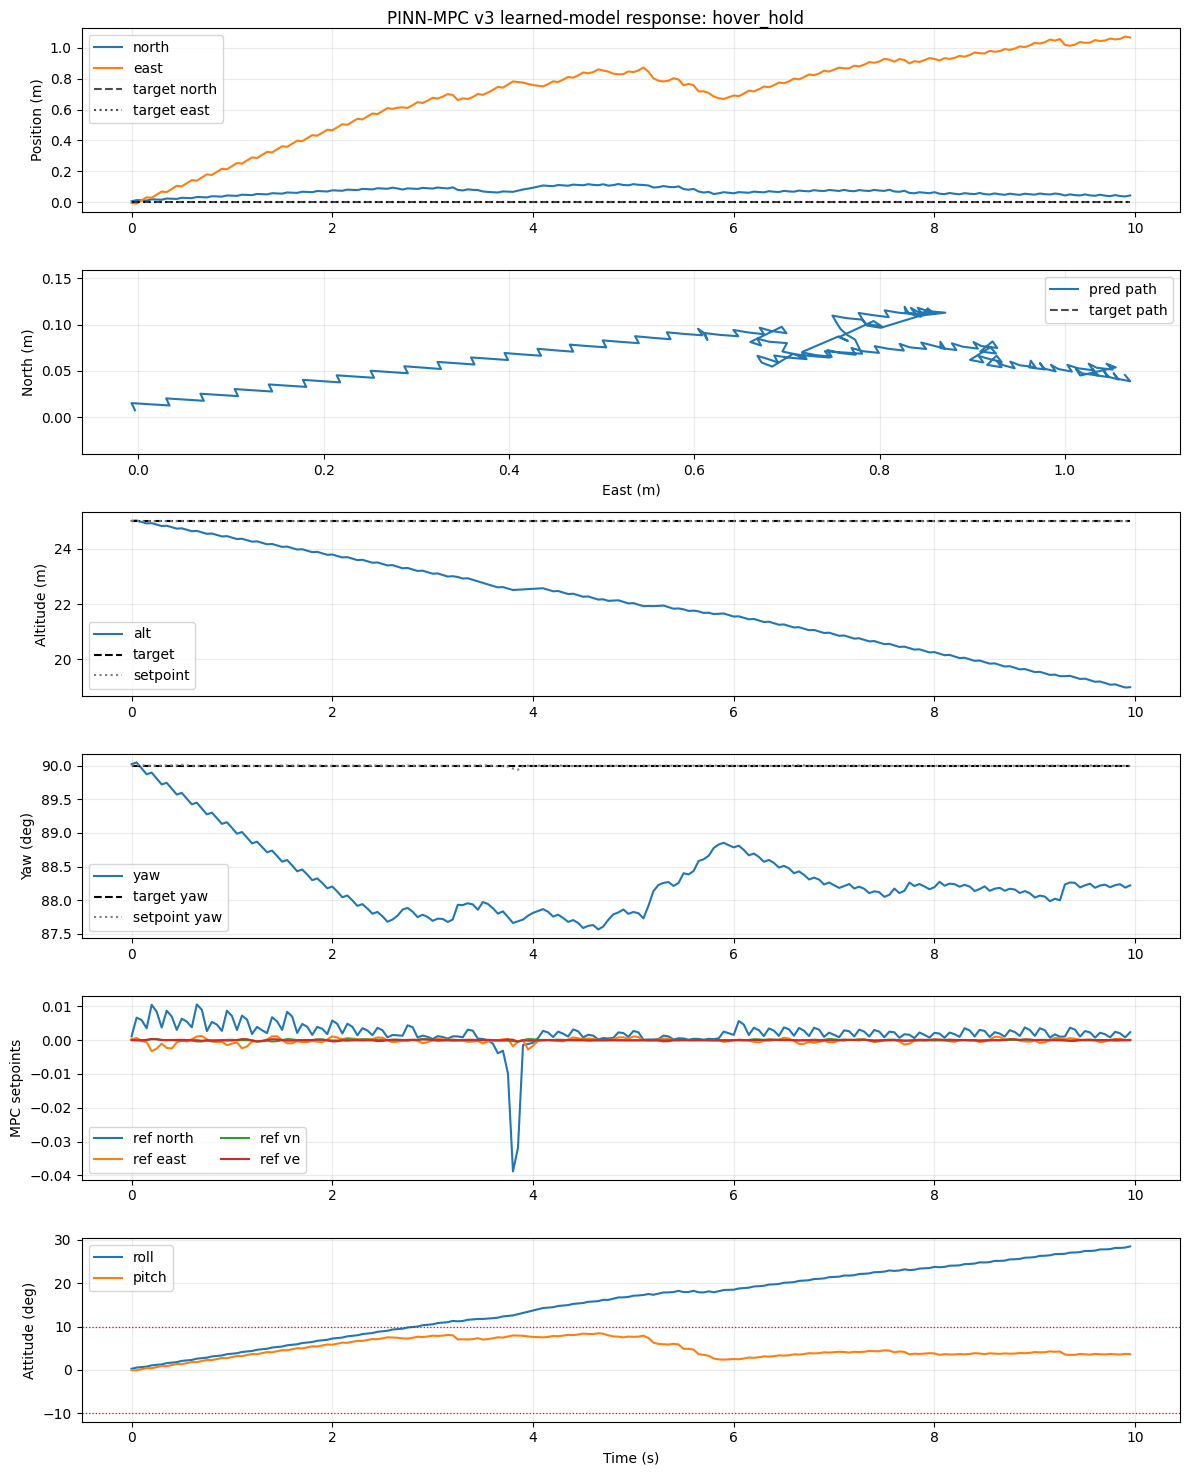

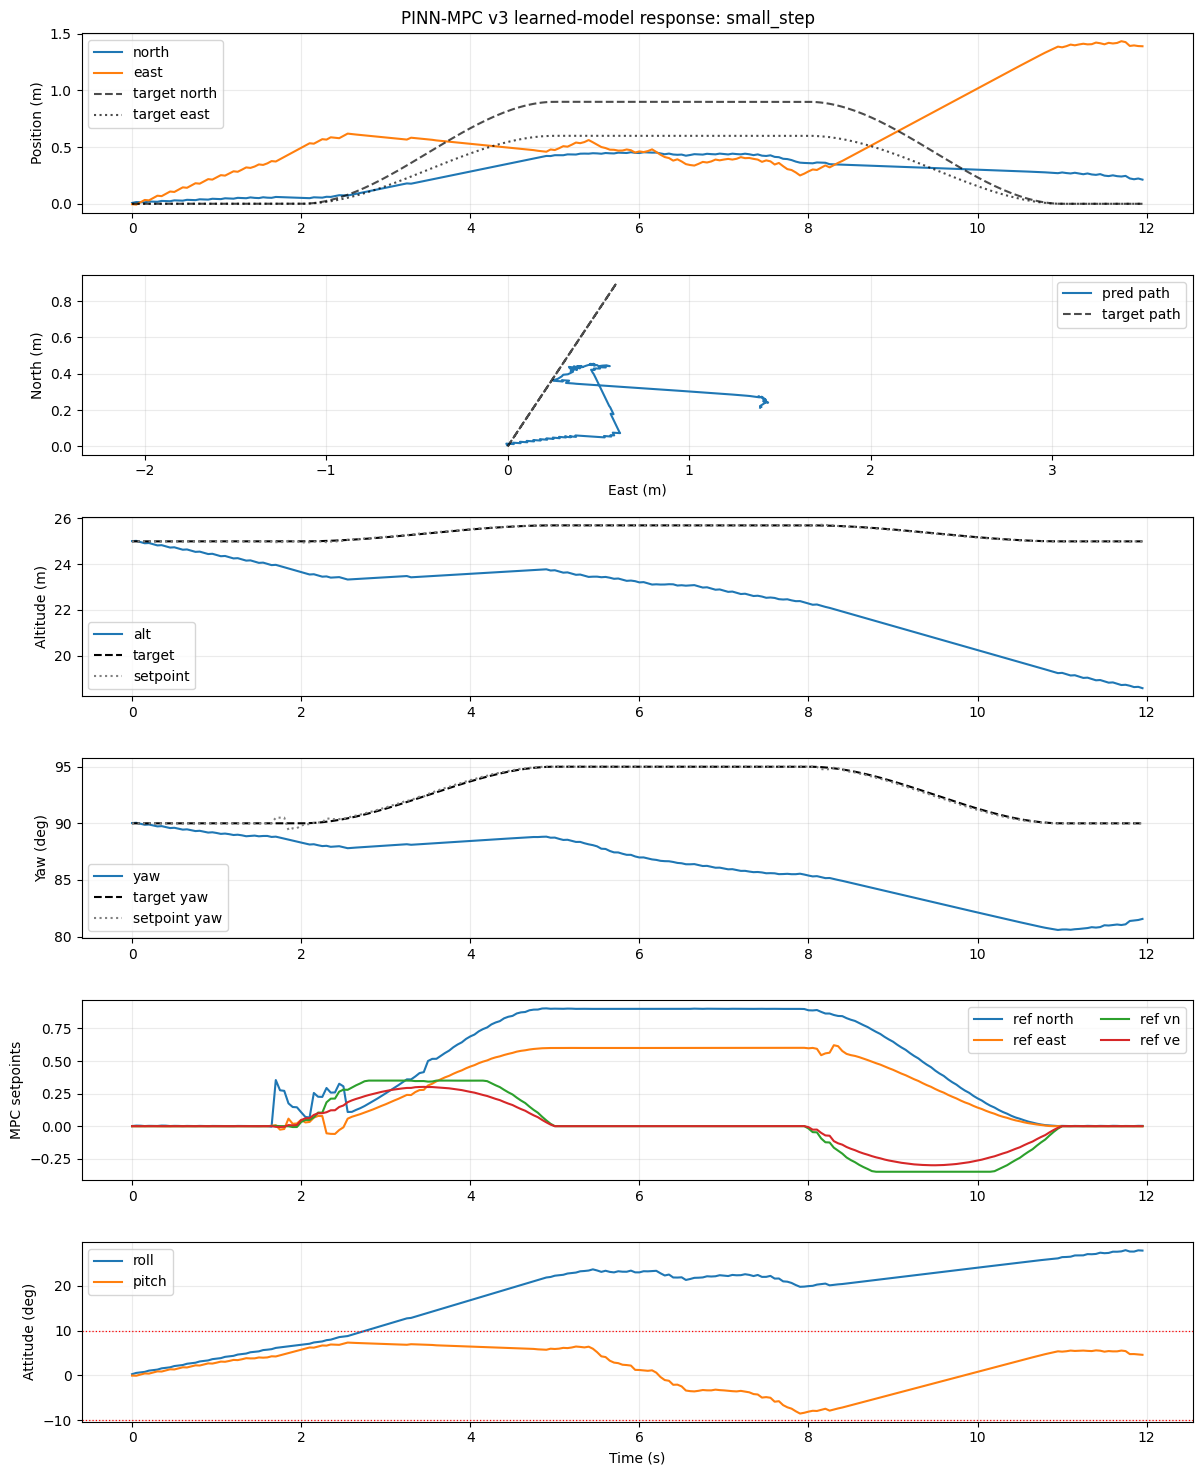

In [27]:
def compute_mpc_metrics(log):
    rows = []
    for scenario, g in log.groupby('scenario'):
        pos_err = np.sqrt((g['north_m'] - g['target_north_m']) ** 2 + (g['east_m'] - g['target_east_m']) ** 2)
        alt_err = g['alt_m'] - g['target_alt_m']
        yaw_err = wrap_deg_np(g['yaw_deg'].to_numpy() - (90.0 + g['target_yaw_offset_deg'].to_numpy()))
        speed = np.sqrt(g['vn_m_s'] ** 2 + g['ve_m_s'] ** 2)
        rows.append({
            'scenario': scenario,
            'pos_rmse_m': float(np.sqrt(np.mean(pos_err ** 2))),
            'pos_final_err_m': float(pos_err.iloc[-1]),
            'alt_rmse_m': float(np.sqrt(np.mean(alt_err ** 2))),
            'alt_final_err_m': float(alt_err.iloc[-1]),
            'yaw_rmse_deg': float(np.sqrt(np.mean(yaw_err ** 2))),
            'yaw_final_err_deg': float(yaw_err[-1]),
            'speed_max_m_s': float(np.max(speed)),
            'max_abs_roll_deg': float(np.max(np.abs(g['roll_deg']))),
            'max_abs_pitch_deg': float(np.max(np.abs(g['pitch_deg']))),
            'safe_candidate': bool(
                np.max(np.abs(g['roll_deg'])) < 12.0
                and np.max(np.abs(g['pitch_deg'])) < 12.0
                and np.max(speed) < 1.0
                and np.sqrt(np.mean(alt_err ** 2)) < 0.8
            ),
        })
    return pd.DataFrame(rows)

mpc_metrics = compute_mpc_metrics(mpc_log)
display(mpc_metrics)

for scenario, g in mpc_log.groupby('scenario'):
    fig, axes = plt.subplots(6, 1, figsize=(12, 15), sharex=False)
    t = g['time_s']
    fig.suptitle(f'PINN-MPC v3 learned-model response: {scenario}')
    axes[0].plot(t, g['north_m'], label='north')
    axes[0].plot(t, g['east_m'], label='east')
    axes[0].plot(t, g['target_north_m'], 'k--', alpha=0.7, label='target north')
    axes[0].plot(t, g['target_east_m'], 'k:', alpha=0.7, label='target east')
    axes[0].set_ylabel('Position (m)')
    axes[0].legend()

    axes[1].plot(g['east_m'], g['north_m'], label='pred path')
    axes[1].plot(g['target_east_m'], g['target_north_m'], 'k--', alpha=0.7, label='target path')
    axes[1].set_ylabel('North (m)')
    axes[1].set_xlabel('East (m)')
    axes[1].axis('equal')
    axes[1].legend()

    axes[2].plot(t, g['alt_m'], label='alt')
    axes[2].plot(t, g['target_alt_m'], 'k--', label='target')
    axes[2].plot(t, g['ref_alt_m'], '0.5', ls=':', label='setpoint')
    axes[2].set_ylabel('Altitude (m)')
    axes[2].legend()

    axes[3].plot(t, g['yaw_deg'], label='yaw')
    axes[3].plot(t, 90.0 + g['target_yaw_offset_deg'], 'k--', label='target yaw')
    axes[3].plot(t, 90.0 + g['ref_yaw_offset_deg'], '0.5', ls=':', label='setpoint yaw')
    axes[3].set_ylabel('Yaw (deg)')
    axes[3].legend()

    axes[4].plot(t, g['ref_north_m'], label='ref north')
    axes[4].plot(t, g['ref_east_m'], label='ref east')
    axes[4].plot(t, g['ref_vn_m_s'], label='ref vn')
    axes[4].plot(t, g['ref_ve_m_s'], label='ref ve')
    axes[4].set_ylabel('MPC setpoints')
    axes[4].legend(ncol=2)

    axes[5].plot(t, g['roll_deg'], label='roll')
    axes[5].plot(t, g['pitch_deg'], label='pitch')
    axes[5].axhline(10.0, color='r', ls=':', lw=0.9)
    axes[5].axhline(-10.0, color='r', ls=':', lw=0.9)
    axes[5].set_ylabel('Attitude (deg)')
    axes[5].set_xlabel('Time (s)')
    axes[5].legend()
    for ax in axes:
        ax.grid(True, alpha=0.25)
    fig.tight_layout()
    plt.show()


In [28]:
if Path('/content/drive/MyDrive').exists():
    SAVE_ROOT = Path('/content/drive/MyDrive/Colab Result/PINN_MPC/px4_phase1_closed_loop_pinn_mpc_v3_stable_hover_tuning')
else:
    SAVE_ROOT = Path('/content/px4_phase1_closed_loop_pinn_mpc_v3_stable_hover_tuning')
SAVE_DIR = SAVE_ROOT / time.strftime('%Y%m%d_%H%M%S')
SAVE_DIR.mkdir(parents=True, exist_ok=True)
mpc_log.to_csv(SAVE_DIR / 'pinn_mpc_v3_learned_model_log.csv', index=False)
mpc_metrics.to_csv(SAVE_DIR / 'pinn_mpc_v3_learned_model_metrics.csv', index=False)
with open(SAVE_DIR / 'config.json', 'w') as f:
    json.dump({
        'revision': NOTEBOOK_REVISION,
        'checkpoint': str(CKPT_PATH),
        'run_scenarios': RUN_SCENARIOS,
        'horizon': MPC_HORIZON,
        'samples': MPC_SAMPLES,
        'elites': MPC_ELITES,
        'iters': MPC_ITERS,
        'control_interval_steps': CONTROL_INTERVAL_STEPS,
        'cost': COST,
        'noise': NOISE,
    }, f, indent=2)
print('saved:', SAVE_DIR)


saved: /content/drive/MyDrive/Colab Result/PINN_MPC/px4_phase1_closed_loop_pinn_mpc_v3_stable_hover_tuning/20260509_233646
